# 01 · Exploratory data analysis

What does the data look like, and how predictable are EPL matches in the first place?
Data: football-data.co.uk, 2017-18 to 2025-26 (plus the first matches of 2026-27), built by `python -m src.data`.

In [1]:
import sys
import warnings
sys.path.insert(0, "..")  # make the project's src/ package importable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", message="IProgress not found")  # harmless notice from shap's progress bar
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "figure.dpi": 110})
OUTCOME_COLORS = {"H": "#2a78d6", "D": "#a3a29c", "A": "#eb6834"}
from src.data import load_processed, season_summary
from src.evaluate import bookmaker_probs

matches = load_processed()
print(matches.shape)
matches.head()

(3470, 22)


,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,AC,HF,AF,HY,AY,HR,AR,B365H,B365D,B365A
0,2017-18,2017-08-11,Arsenal,Leicester,4,3,H,27,6,10,...,4,9,12,0,1,0,0,1.53,4.5,6.50
1,2017-18,2017-08-12,Brighton,Man City,0,2,A,6,14,2,...,10,6,9,0,2,0,0,11.00,5.5,1.33
2,2017-18,2017-08-12,Chelsea,Burnley,2,3,A,19,10,6,...,5,16,11,3,3,2,0,1.25,6.5,15.00
3,2017-18,2017-08-12,Crystal Palace,Huddersfield,0,3,A,14,8,4,...,9,7,19,1,3,0,0,1.83,3.6,5.00
4,2017-18,2017-08-12,Everton,Stoke,1,0,H,9,9,4,...,7,13,10,1,1,0,0,1.70,3.8,5.75


## Per-season summary
20 teams and 380 matches in every completed season, and no missing Bet365 odds.

In [2]:
season_summary(matches)

,matches,teams,home_win,draw,away_win,missing_odds
Season,,,,,,
2017-18,380,20,0.455,0.261,0.284,0
2018-19,380,20,0.476,0.187,0.337,0
2019-20,380,20,0.453,0.242,0.305,0
2020-21,380,20,0.379,0.218,0.403,0
2021-22,380,20,0.429,0.232,0.339,0
2022-23,380,20,0.484,0.229,0.287,0
2023-24,380,20,0.461,0.216,0.324,0
2024-25,380,20,0.408,0.245,0.347,0
2025-26,380,20,0.426,0.274,0.300,0


## Outcome rates by season
Home wins are the most common result, but the home edge is not constant. In **2020-21** (matches behind closed doors
because of COVID) away wins outnumbered home wins, the clearest evidence that crowds drive much of home advantage.
Draws sit at roughly a quarter of matches; 2025-26 had the most draws (27.4%) of any completed season.

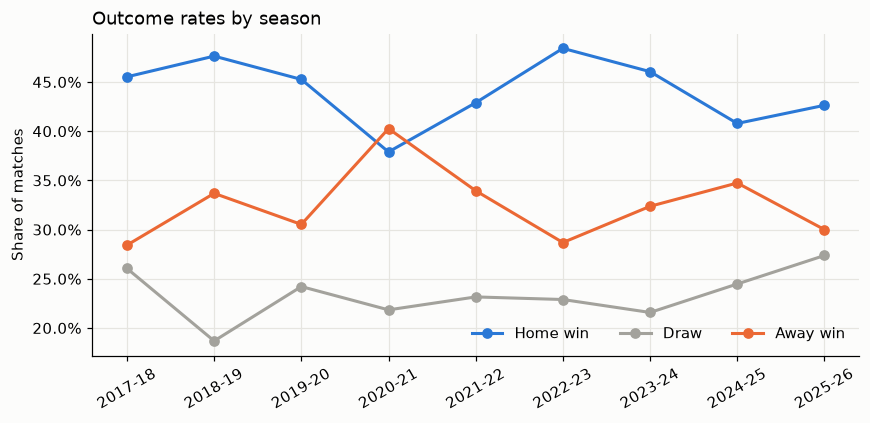

In [3]:
completed = matches[matches["Season"] < "2026-27"]  # 2026-27 has only 50 matches so far
rates = pd.crosstab(completed["Season"], completed["FTR"], normalize="index")[["H", "D", "A"]]
fig, ax = plt.subplots(figsize=(9, 3.8))
for outcome, label in [("H", "Home win"), ("D", "Draw"), ("A", "Away win")]:
    ax.plot(rates.index, rates[outcome], marker="o", linewidth=2, color=OUTCOME_COLORS[outcome], label=label)
ax.set_ylabel("Share of matches")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(frameon=False, ncols=3)
ax.set_title("Outcome rates by season", loc="left")
plt.xticks(rotation=30)
plt.show()

## Goals
Home teams score a bit more on average. Low scores make football noisy: one deflection often decides a match.

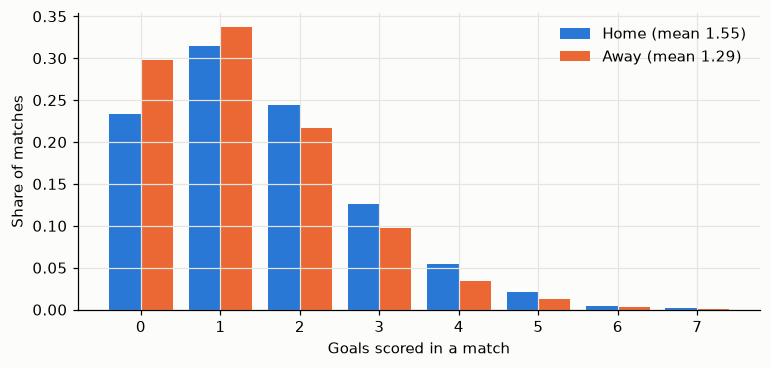

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))
goals = np.arange(0, 8)
width = 0.4
ax.bar(goals - width / 2, matches["FTHG"].value_counts(normalize=True).reindex(goals, fill_value=0), width,
       color=OUTCOME_COLORS["H"], label=f"Home (mean {matches['FTHG'].mean():.2f})")
ax.bar(goals + width / 2, matches["FTAG"].value_counts(normalize=True).reindex(goals, fill_value=0), width,
       color=OUTCOME_COLORS["A"], label=f"Away (mean {matches['FTAG'].mean():.2f})")
ax.set_xlabel("Goals scored in a match")
ax.set_ylabel("Share of matches")
ax.legend(frameon=False)
plt.show()

## How predictable is each season? The bookmaker as a yardstick
Bet365's odds include a margin (the implied probabilities sum to more than 1). Rescaling them to sum to 1 gives a
strong benchmark. Scoring it season by season shows how predictable each season was. **2025-26, our test season, is the
least predictable season in the data, even for the bookmaker.** Keep that in mind when reading the test results.

In [5]:
from sklearn.metrics import log_loss

played = matches[matches["Season"] < "2026-27"].copy()
y = played["FTR"].map({"H": 0, "D": 1, "A": 2}).to_numpy()
book = bookmaker_probs(played)
played["overround"] = (1 / played[["B365H", "B365D", "B365A"]]).sum(axis=1) - 1

rows = []
for season, idx in played.groupby("Season").indices.items():
    rows.append({"Season": season,
                 "bookmaker_log_loss": log_loss(y[idx], book[idx], labels=[0, 1, 2]),
                 "bookmaker_accuracy": (book[idx].argmax(axis=1) == y[idx]).mean(),
                 "mean_margin": played["overround"].iloc[idx].mean()})
pd.DataFrame(rows).round(4)

,Season,bookmaker_log_loss,bookmaker_accuracy,mean_margin
0,2017-18,0.9455,0.5526,0.0311
1,2018-19,0.8929,0.5868,0.0278
2,2019-20,0.9732,0.5289,0.0531
3,2020-21,1.0070,0.5184,0.0545
4,2021-22,0.9372,0.5816,0.0541
5,2022-23,0.9662,0.5579,0.0537
6,2023-24,0.9092,0.5974,0.0540
7,2024-25,0.9708,0.5395,0.0553
8,2025-26,1.0185,0.4895,0.0552


## The bookmaker never predicts a draw
The favourite is almost always the home or away side. Draw probabilities stay in a narrow band and never exceed 34%,
so "most likely outcome" accuracy can never credit a draw. That is why log loss and the Brier score, which judge
the whole probability distribution, are the main metrics in this project.

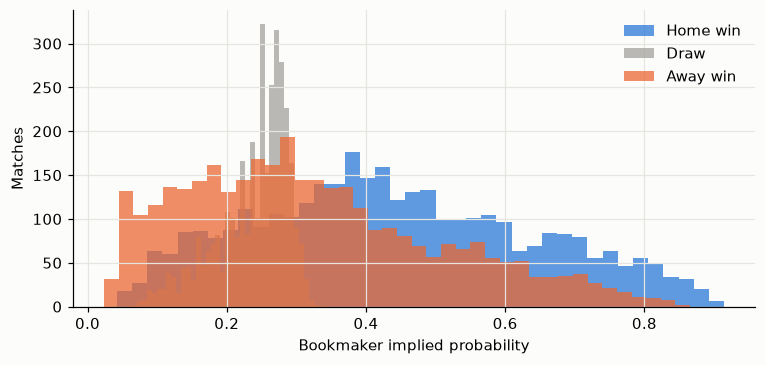

Highest draw probability ever offered: 33.9%; matches where draw was the favourite: 0


In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for k, (outcome, label) in enumerate([("H", "Home win"), ("D", "Draw"), ("A", "Away win")]):
    ax.hist(book[:, k], bins=40, alpha=0.75, color=OUTCOME_COLORS[outcome], label=label)
ax.set_xlabel("Bookmaker implied probability")
ax.set_ylabel("Matches")
ax.legend(frameon=False)
plt.show()
print(f"Highest draw probability ever offered: {book[:, 1].max():.1%}; "
      f"matches where draw was the favourite: {(book.argmax(axis=1) == 1).sum()}")

## Does Elo carry signal?
Elo difference (home minus away, before kickoff) separates outcomes clearly: the home-win rate climbs from about 20%
to about 70% across Elo-difference quintiles. The draw rate moves much less (17–28%), and it is lowest in the most lopsided matches.

In [7]:
from src.features import build_features

features = build_features(matches).dropna(subset=["target"])
quintile = pd.qcut(features["elo_diff"], 5, labels=["Away much stronger", "Away stronger", "Even", "Home stronger", "Home much stronger"])
pd.crosstab(quintile, features["FTR"], normalize="index")[["H", "D", "A"]].round(3)

FTR,H,D,A
elo_diff,,,
Away much stronger,0.197,0.232,0.571
Away stronger,0.337,0.236,0.427
Even,0.427,0.262,0.311
Home stronger,0.533,0.275,0.192
Home much stronger,0.706,0.169,0.125


## Takeaways
- Home advantage is real but varies (it nearly vanished without crowds in 2020-21).
- Draws (~25%) are never the bookmaker's favourite, so accuracy is a poor metric for this problem.
- 2025-26 was unusually unpredictable: Bet365 managed only 48.9% accuracy, against 51.8–59.7% in every other season.
- Elo difference alone carries most of the signal, which shapes the model choices in `02_model_experiments.ipynb`.